# Q4 — Counterfactual / What-If Analysis
Validates `src/xai/counterfactual.py`.

Answers: **What would happen to the forecast if I change price, discount, or SNAP eligibility?**

## 1) Imports and Paths

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sys

sys.path.insert(0, str(Path('..').resolve() / 'src'))

from xai.counterfactual import (
    generate_counterfactual,
    batch_counterfactuals,
    partial_dependence,
    generate_counterfactual_text,
)

ROOT       = Path('..').resolve()
DATA_DIR   = ROOT / 'data' / 'processed' / 'LGBM_XGB_7_V3'
MODEL_PATH = ROOT / 'artifacts' / 'models' / 'tuned_lgbm_7_v3.joblib'

print('MODEL_PATH:', MODEL_PATH)

MODEL_PATH: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\models\tuned_lgbm_7_v3.joblib


## 2) Load Model and Data

In [2]:
model   = joblib.load(MODEL_PATH)
test_df = pd.read_csv(DATA_DIR / 'test.csv')
test_df['date'] = pd.to_datetime(test_df['date'], errors='coerce')

TARGET    = 'aggregated_sales_7'
DROP_COLS = [TARGET, 'date', 'item_id']
feature_cols = [c for c in test_df.columns if c not in DROP_COLS]

X_test = test_df[feature_cols].copy()

# Pick a mid-selling SKU for clear what-if results
sku_means  = test_df.groupby('item_id')[TARGET].mean()
target_sku = sku_means[(sku_means > 5) & (sku_means < 30)].index[0]
target_idx = test_df[test_df['item_id'] == target_sku].index[0]
X_row      = X_test.loc[[target_idx]]

print(f'Chosen SKU:  {target_sku}')
print(f'Base prediction: {model.predict(X_row)[0]:.2f} units')
print(f'\nFeature values for this row:')
print(X_row.T.rename(columns={target_idx: 'value'}).to_string())

Chosen SKU:  FOODS_1_001
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
Base prediction: 4.54 units

Feature values for this row:
                                value
is_month_end                 0.000000
sales_lag_7                  8.000000
sales_roll_mean_7            8.000000
aggregated_sell_price        2.240000
discount_depth               0.000000
event_christmas_7            0.000000
event_easter_7               0.000000
event_eid_al_fitr_7          0.000000
event_eid_al_adha_7          0.000000
event_fathers_day_7          0.000000
event_halloween_7            0.000000
event_mothers_day_7          0.000000
event_newyear_7              0.000000
event_orthodox_christmas_7   0.000000
event_orthodox_easter_7      0.000000
event_ra

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\e

## 3) Single Counterfactual — Price Change

In [3]:
original_price = float(X_row['aggregated_sell_price'].iloc[0])
new_price      = original_price * 0.85  # 15% price reduction

result = generate_counterfactual(model, X_row, 'aggregated_sell_price', new_price)
print('Price counterfactual (−15%):')
for k, v in result.items():
    print(f'  {k:25s}: {v}')

print()
text = generate_counterfactual_text(
    sku_id               = target_sku,
    feature              = 'aggregated_sell_price',
    original_feature_val = result['original_feature_val'],
    new_feature_val      = result['new_feature_val'],
    original_pred        = result['original_pred'],
    new_pred             = result['counterfactual_pred'],
    delta                = result['delta'],
)
print(text)

[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
Price counterfactual (−15%):
  original_feature_val     : 2.24
  new_feature_val          : 1.9040000000000001
  original_pred            : 4.5419
  counterfactual_pred      : 4.5679
  delta                    : 0.0259

=== What-If Analysis: FOODS_1_001 ===
Feature changed: aggregated sell price
  Before: 2.24  →  After: 1.904

Forecast before change: 4.5 units
Forecast after  change: 4.6 units


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 4) Single Counterfactual — SNAP Toggle

In [4]:
current_snap = int(X_row['snap_relevant'].iloc[0])
new_snap     = 1 - current_snap  # toggle

result_snap = generate_counterfactual(model, X_row, 'snap_relevant', new_snap)
print(f'SNAP toggle ({current_snap} → {new_snap}):')
for k, v in result_snap.items():
    print(f'  {k:25s}: {v}')

print()
text_snap = generate_counterfactual_text(
    sku_id               = target_sku,
    feature              = 'snap_relevant',
    original_feature_val = result_snap['original_feature_val'],
    new_feature_val      = result_snap['new_feature_val'],
    original_pred        = result_snap['original_pred'],
    new_pred             = result_snap['counterfactual_pred'],
    delta                = result_snap['delta'],
)
print(text_snap)

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
SNAP toggle (0 → 1):
  original_feature_val     : 0.0
  new_feature_val          : 1.0
  original_pred            : 4.5419
  counterfactual_pred      : 4.6131
  delta                    : 0.0712

=== What-If Analysis: FOODS_1_001 ===
Feature changed: snap relevant
  Before: 0  →  After: 1

Forecast before change: 4.5 units
Forecast after  change: 4.6 units
Impact: +0.1 units (1.6% increase)
Inte

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 5) Batch Counterfactual — Price Sweep

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ign

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserW

[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ign

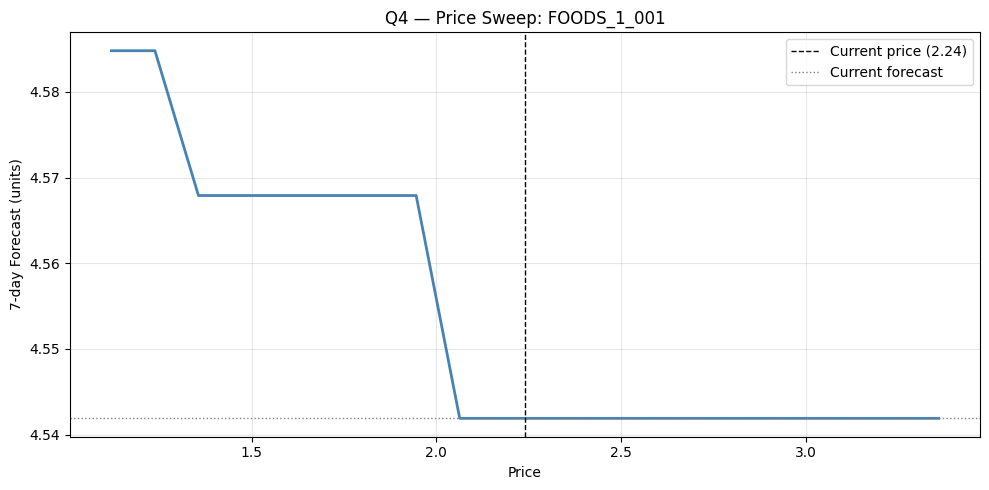

In [5]:
price_values = np.linspace(original_price * 0.5, original_price * 1.5, 20)
batch_df     = batch_counterfactuals(model, X_row, 'aggregated_sell_price', price_values)

print(batch_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(batch_df['feature_value'], batch_df['prediction'], color='steelblue', linewidth=2)
ax.axvline(original_price, color='black', linestyle='--', linewidth=1, label=f'Current price ({original_price:.2f})')
ax.axhline(float(model.predict(X_row)[0]), color='gray', linestyle=':', linewidth=1, label='Current forecast')
ax.set_xlabel('Price')
ax.set_ylabel('7-day Forecast (units)')
ax.set_title(f'Q4 — Price Sweep: {target_sku}')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6) Batch Counterfactual — Discount Depth Sweep

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserW

[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ign

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserW

[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ign

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231


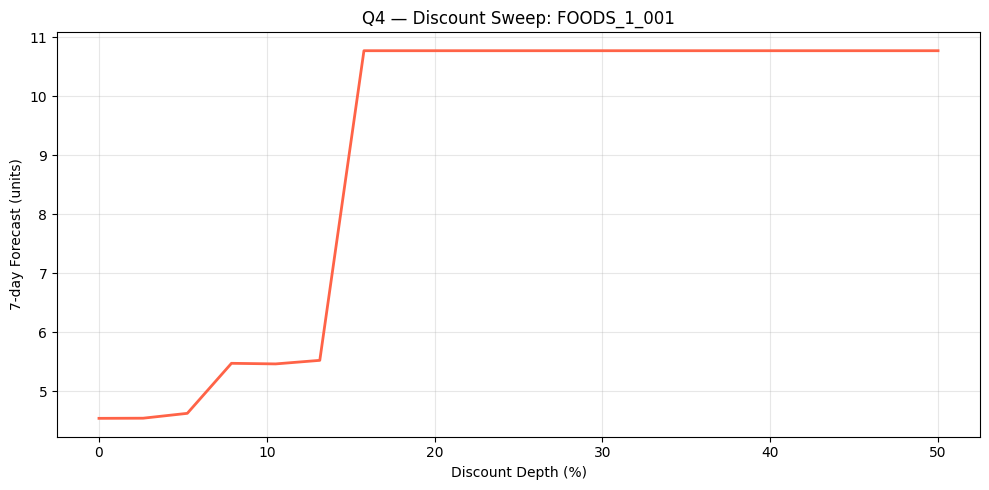

In [6]:
discount_values = np.linspace(0.0, 0.5, 20)  # 0% to 50% discount
batch_disc      = batch_counterfactuals(model, X_row, 'discount_depth', discount_values)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(batch_disc['feature_value'] * 100, batch_disc['prediction'], color='tomato', linewidth=2)
ax.set_xlabel('Discount Depth (%)')
ax.set_ylabel('7-day Forecast (units)')
ax.set_title(f'Q4 — Discount Sweep: {target_sku}')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7) Partial Dependence Plot — Price

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ign

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231


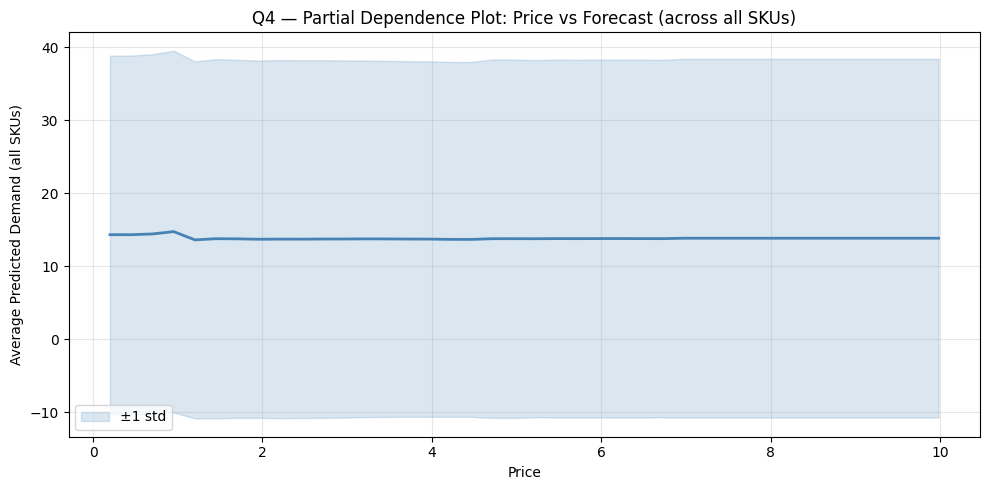

 feature_value  avg_prediction  std_prediction
        0.2000         14.3044         24.5531
        0.4508         14.3044         24.5531
        0.7015         14.4076         24.6436
        0.9523         14.7288         24.7978
        1.2031         13.5964         24.4648
        1.4538         13.7569         24.6204
        1.7046         13.7359         24.5411
        1.9554         13.6835         24.4924
        2.2062         13.7004         24.5470
        2.4569         13.6943         24.5198
        2.7077         13.7123         24.5122
        2.9585         13.7158         24.4846
        3.2092         13.7321         24.4341
        3.4600         13.7257         24.4068
        3.7108         13.7091         24.3743
        3.9615         13.7035         24.3695
        4.2123         13.6645         24.3221
        4.4631         13.6593         24.3224
        4.7138         13.7566         24.5649
        4.9646         13.7579         24.5648
        5.215

In [7]:
pdp_price = partial_dependence(model, X_test, 'aggregated_sell_price', grid_resolution=40)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pdp_price['feature_value'], pdp_price['avg_prediction'], color='steelblue', linewidth=2)
ax.fill_between(
    pdp_price['feature_value'],
    pdp_price['avg_prediction'] - pdp_price['std_prediction'],
    pdp_price['avg_prediction'] + pdp_price['std_prediction'],
    alpha=0.2, color='steelblue', label='±1 std'
)
ax.set_xlabel('Price')
ax.set_ylabel('Average Predicted Demand (all SKUs)')
ax.set_title('Q4 — Partial Dependence Plot: Price vs Forecast (across all SKUs)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(pdp_price.to_string(index=False))

## 8) Partial Dependence Plot — SNAP

[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


PDP — SNAP (0=off, 1=on):
 feature_value  avg_prediction  std_prediction
           0.0         13.6646         24.5090
           1.0         13.9701         24.9715


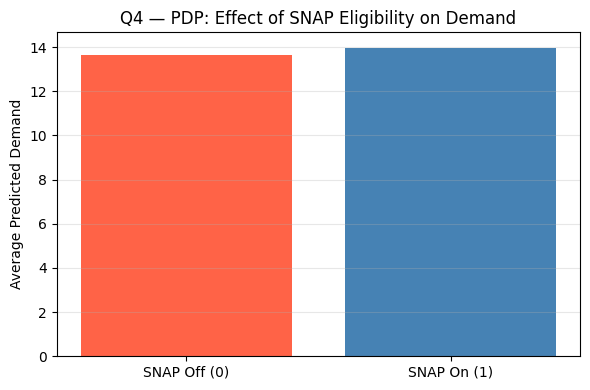

In [8]:
pdp_snap = partial_dependence(model, X_test, 'snap_relevant', grid_resolution=2)
print('PDP — SNAP (0=off, 1=on):')
print(pdp_snap.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['SNAP Off (0)', 'SNAP On (1)'], pdp_snap['avg_prediction'], color=['tomato', 'steelblue'])
ax.set_ylabel('Average Predicted Demand')
ax.set_title('Q4 — PDP: Effect of SNAP Eligibility on Demand')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()